# CARMS — Phase 3 Regime Detection Exploration
Visualise detected market regimes, transition dynamics, and per-regime statistics.

**Sections**
1. Setup & validation
2. Regime timeline — when was each regime active?
3. Regime duration statistics
4. Transition probability heatmap
5. Return & risk statistics per regime
6. Regime in state vector space (t-SNE)
7. Per-asset regime behaviour
8. Regime probability (soft assignments) over time

In [1]:
import os, sys
from pathlib import Path
root = Path(os.getcwd())
for _ in range(5):
    if (root / 'main.py').exists(): break
    root = root.parent
os.chdir(root)
if str(root) not in sys.path: sys.path.insert(0, str(root))
print(f'Root: {root}')

Root: C:\Users\Mugithi\Documents\carms


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
Path('logs').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.3,
    'axes.spines.top':False,'axes.spines.right':False,'font.size':10
})

from src.utils.logger import load_config
from src.features.indicators import load_features
from src.regime.hmm_detector import load_regime_labels, load_hmm, REGIME_NAMES, REGIME_COLOURS
from src.regime.phase3_runner import validate_phase3

config = load_config('configs/config.yaml')
config['_base_dir'] = str(root)
for key in ['raw_dir','processed_dir','charts_dir']:
    config['data'][key] = str((root/config['data'][key]).resolve())
MODEL_DIR = str(root / 'models')
SYMBOL    = 'BTC-USD'
print('✓ Ready')

✓ Ready


## 1 — Validation

In [3]:
validate_phase3(config, MODEL_DIR)


────────────────────────────────────────────────────────────
  CARMS Phase 3 — Validation Report
────────────────────────────────────────────────────────────

  HMM Model
13:05:20 INFO     [hmm_detector] Loaded HMM from C:\Users\Mugithi\Documents\carms\models\hmm_regime_detector.pkl
    ✓ hmm_regime_detector.pkl  (n_states=4  converged=True)

  Regime Labels
    ✓ regime_labels.parquet  1,395 days labelled
       crisis                 725 days  (52.0%)
       trending_down          410 days  (29.4%)
       trending_up            175 days  (12.5%)
       ranging                 85 days  (6.1%)

  Analysis Outputs
    ✓ regime_durations.csv
    ✓ regime_transitions.csv
    ✓ regime_return_stats.csv

  Regime-Labelled State Vectors
    ✓ EURUSD=X         1,450 labelled  regime cols: True
    ✓ KES=X            1,450 labelled  regime cols: True
    ✓ BTC-USD          2,077 labelled  regime cols: True
    ✓ ETH-USD          2,077 labelled  regime cols: True
    ✓ GC=F             1,395 la

True

## 2 — Regime timeline

In [4]:
labels_df = load_regime_labels(MODEL_DIR)
price_df  = load_features(SYMBOL)

if labels_df is None:
    print('No regime labels — run: python main.py --phase 3')
else:
    print(f'Regime labels: {len(labels_df):,} days  ({labels_df.index[0].date()} → {labels_df.index[-1].date()})')
    print(labels_df['regime_name'].value_counts().to_string())

Regime labels: 1,395 days  (2019-06-10 → 2024-12-20)
regime_name
crisis           725
trending_down    410
trending_up      175
ranging           85


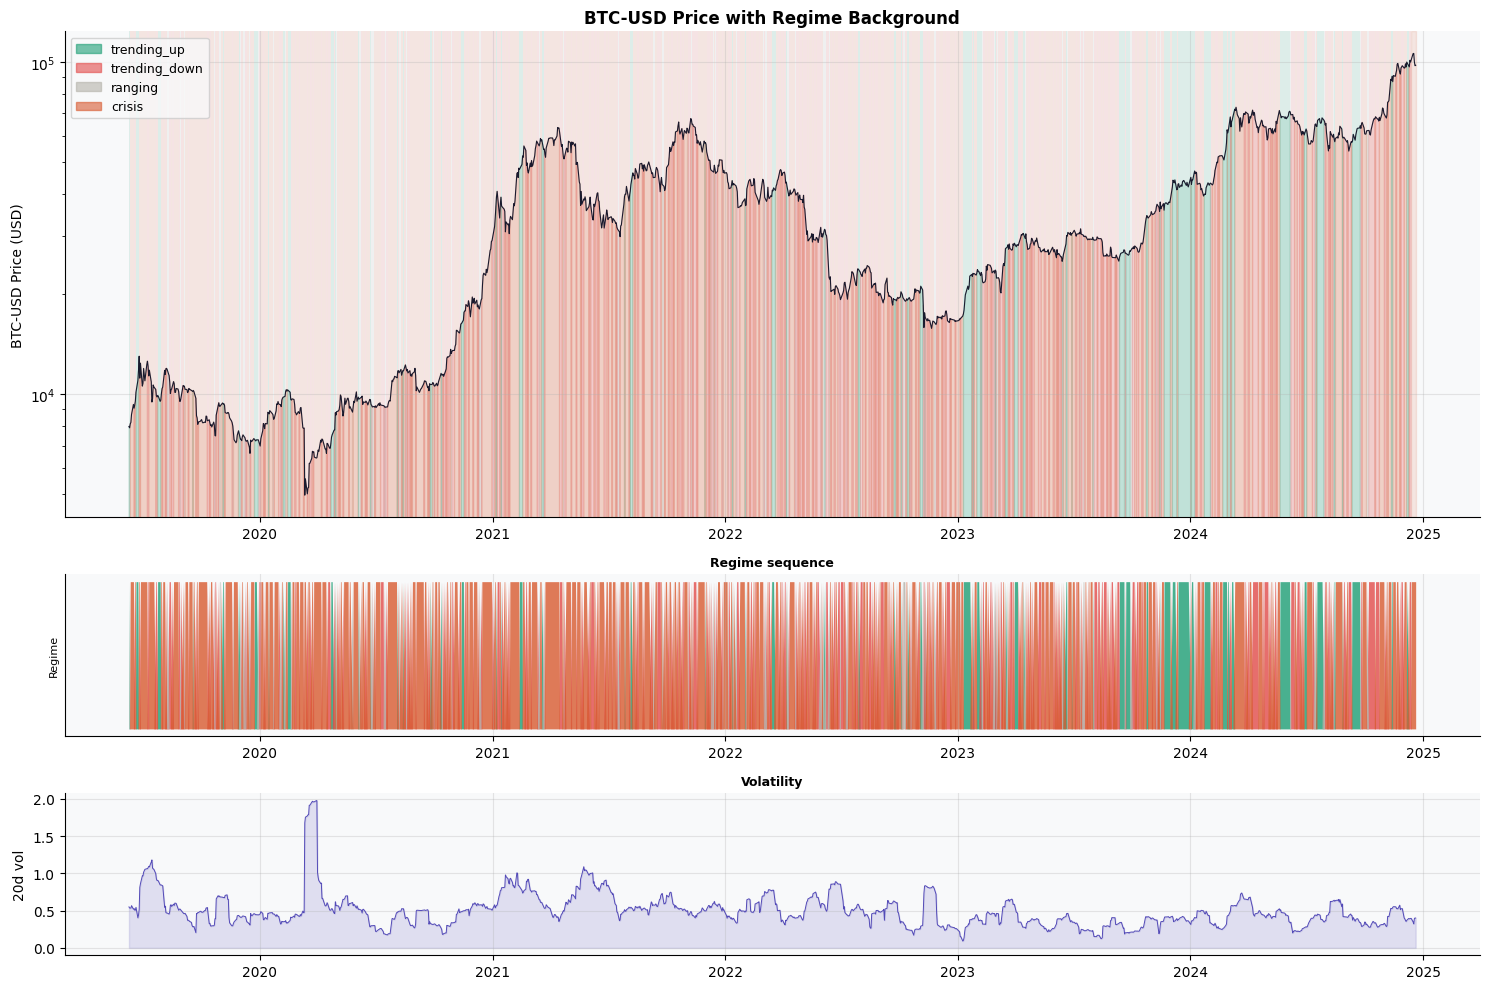

Saved → logs/p3_01_regime_timeline.png


In [5]:
if labels_df is not None and price_df is not None:
    RCOLOURS = {
        'trending_up':   '#1D9E75',
        'trending_down': '#E24B4A',
        'ranging':       '#B4B2A9',
        'crisis':        '#D85A30',
    }

    close = price_df['close'].reindex(labels_df.index)

    fig, axes = plt.subplots(3, 1, figsize=(15, 10),
                              gridspec_kw={'height_ratios':[3,1,1]})

    # Panel 1: price coloured by regime
    ax = axes[0]
    prev_regime = None
    seg_start   = labels_df.index[0]
    for i, (date, row) in enumerate(labels_df.iterrows()):
        name = row['regime_name']
        if name != prev_regime and prev_regime is not None:
            seg = close.loc[seg_start:date]
            ax.fill_between(seg.index, 0, seg.values,
                             alpha=0.15, color=RCOLOURS.get(prev_regime,'#888'))
            seg_start = date
        prev_regime = name

    ax.plot(close.index, close.values, color='#1a1a2e', linewidth=0.8, zorder=5)

    # Colour background spans
    for name, colour in RCOLOURS.items():
        mask = labels_df['regime_name'] == name
        dates_r = labels_df.index[mask]
        if len(dates_r) == 0: continue
        # Group into contiguous spans
        in_span = False
        span_start = None
        for j in range(len(labels_df)):
            d = labels_df.index[j]
            is_this = labels_df['regime_name'].iloc[j] == name
            if is_this and not in_span:
                span_start = d; in_span = True
            elif not is_this and in_span:
                ax.axvspan(span_start, d, alpha=0.12, color=colour, linewidth=0)
                in_span = False
        if in_span:
            ax.axvspan(span_start, labels_df.index[-1], alpha=0.12, color=colour)

    ax.set_ylabel(f'{SYMBOL} Price (USD)')
    ax.set_title(f'{SYMBOL} Price with Regime Background', fontweight='bold')
    ax.set_yscale('log')
    legend_patches = [mpatches.Patch(color=c, label=n, alpha=0.6)
                       for n, c in RCOLOURS.items()]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Panel 2: regime as coloured bar
    ax2 = axes[1]
    for name, colour in RCOLOURS.items():
        mask = (labels_df['regime_name'] == name).astype(float)
        ax2.fill_between(labels_df.index, 0, mask, color=colour, alpha=0.8, linewidth=0)
    ax2.set_yticks([])
    ax2.set_ylabel('Regime', fontsize=8)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.set_title('Regime sequence', fontweight='bold', fontsize=9)

    # Panel 3: volatility
    ax3 = axes[2]
    vol = price_df['volatility_20'].reindex(labels_df.index)
    ax3.plot(vol.index, vol.values, color='#534AB7', linewidth=0.7)
    ax3.fill_between(vol.index, vol.values, alpha=0.15, color='#534AB7')
    ax3.set_ylabel('20d vol')
    ax3.set_title('Volatility', fontweight='bold', fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig('logs/p3_01_regime_timeline.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved → logs/p3_01_regime_timeline.png')

## 3 — Duration statistics

Regime Duration Statistics (days)
               mean_days  median_days  max_days  min_days  n_episodes
regime_name                                                          
crisis               2.4          2.0        16         1         296
ranging              1.0          1.0         2         1          82
trending_down        1.4          1.0         8         1         285
trending_up          2.5          1.0        12         1          70


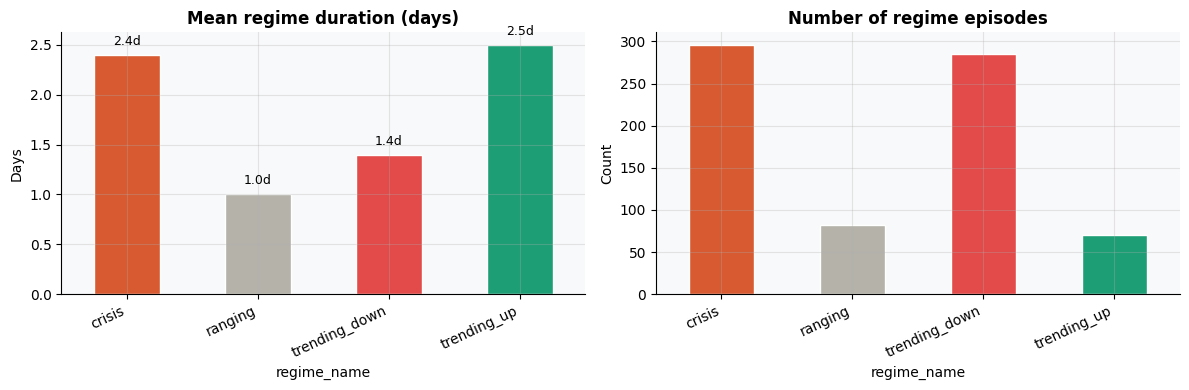

In [6]:
from src.regime.regime_analyser import _compute_durations
if labels_df is not None:
    dur = _compute_durations(labels_df)
    print('Regime Duration Statistics (days)')
    print('='*55)
    print(dur.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colours = [RCOLOURS.get(n,'#888') for n in dur.index]

    dur['mean_days'].plot(kind='bar', ax=axes[0], color=colours, edgecolor='white')
    axes[0].set_title('Mean regime duration (days)', fontweight='bold')
    axes[0].set_ylabel('Days')
    axes[0].set_xticklabels(dur.index, rotation=25, ha='right')
    for bar, v in zip(axes[0].patches, dur['mean_days']):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f'{v:.1f}d', ha='center', fontsize=9)

    dur['n_episodes'].plot(kind='bar', ax=axes[1], color=colours, edgecolor='white')
    axes[1].set_title('Number of regime episodes', fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xticklabels(dur.index, rotation=25, ha='right')

    plt.tight_layout()
    plt.savefig('logs/p3_02_durations.png', dpi=130, bbox_inches='tight')
    plt.show()

## 4 — Transition probability heatmap

Transition Probability Matrix
(rows = from, cols = to)
               trending_up  trending_down  ranging  crisis
trending_up          0.600          0.057    0.160   0.183
trending_down        0.017          0.305    0.085   0.593
ranging              0.047          0.671    0.035   0.247
crisis               0.080          0.301    0.026   0.593

Mean diagonal (persistence): 38.3%
Interpretation: on average, 38.3% chance of staying in same regime tomorrow


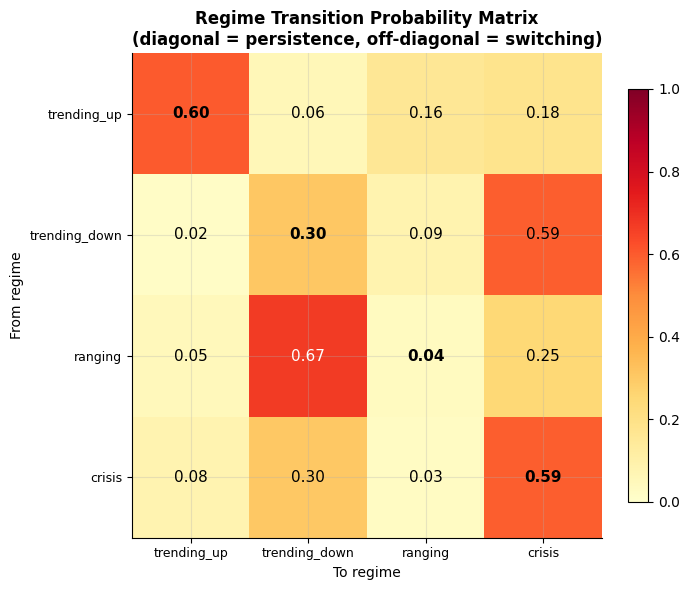

In [7]:
from src.regime.regime_analyser import _compute_transitions
if labels_df is not None:
    trans = _compute_transitions(labels_df)
    print('Transition Probability Matrix')
    print('(rows = from, cols = to)')
    print(trans.to_string())
    diag = np.diag(trans.values)
    print(f'\nMean diagonal (persistence): {diag.mean():.1%}')
    print(f'Interpretation: on average, {diag.mean():.1%} chance of staying in same regime tomorrow')

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(trans.values, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(trans.columns, fontsize=9)
    ax.set_yticklabels(trans.index, fontsize=9)
    ax.set_xlabel('To regime')
    ax.set_ylabel('From regime')
    for i in range(4):
        for j in range(4):
            v = trans.values[i,j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=11, fontweight='bold' if i==j else 'normal',
                     color='white' if v > 0.6 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.04)
    ax.set_title('Regime Transition Probability Matrix\n'
                  '(diagonal = persistence, off-diagonal = switching)',
                  fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p3_03_transitions.png', dpi=130, bbox_inches='tight')
    plt.show()

## 5 — Return & risk per regime

Return & Risk Statistics per Regime (BTC reference)
               n_days  mean_ret_%  std_ret_%  sharpe  win_rate_%  mean_vol  max_drawdown_%
regime                                                                                    
trending_up       175       1.297      2.691    7.65        64.6    0.4344          -10.93
trending_down     410      -1.736      3.094   -8.91        22.7    0.4772          -99.95
ranging            85      -1.683      2.958   -9.03        11.8    0.4407          -82.24
crisis            725       1.312      3.913    5.32        67.0    0.5291          -38.59


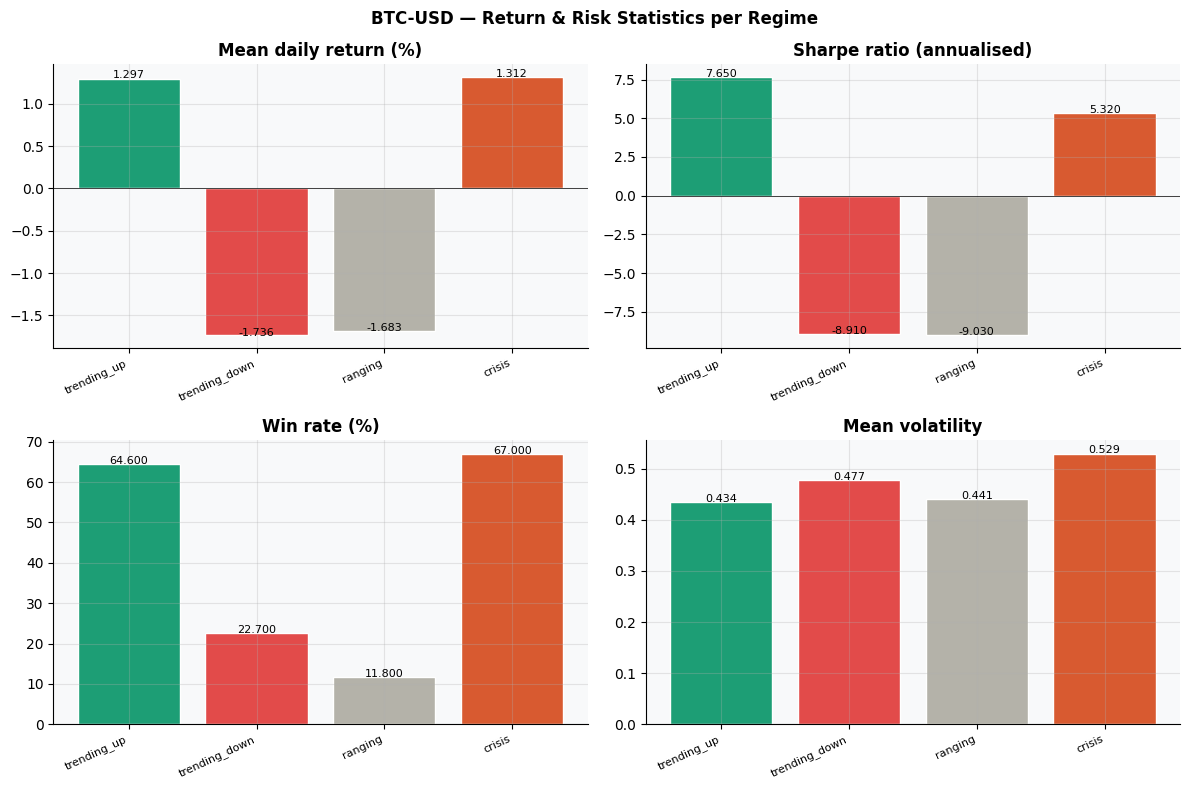

In [8]:
from src.regime.regime_analyser import _compute_return_stats
if labels_df is not None:
    ret_stats = _compute_return_stats(labels_df, config)
    print('Return & Risk Statistics per Regime (BTC reference)')
    print('='*65)
    print(ret_stats.to_string())

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    metrics = ['mean_ret_%','sharpe','win_rate_%','mean_vol']
    titles  = ['Mean daily return (%)', 'Sharpe ratio (annualised)',
                'Win rate (%)', 'Mean volatility']

    for ax, metric, title in zip(axes.flat, metrics, titles):
        vals    = ret_stats[metric]
        colours = [RCOLOURS.get(n,'#888') for n in vals.index]
        bars    = ax.bar(vals.index, vals.values, color=colours, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=8)
        ax.axhline(0, color='black', linewidth=0.5)
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_x()+bar.get_width()/2,
                     bar.get_height() + (0.001 if v >= 0 else -0.003),
                     f'{v:.3f}', ha='center', fontsize=8)

    plt.suptitle(f'{SYMBOL} — Return & Risk Statistics per Regime', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p3_04_return_stats.png', dpi=130, bbox_inches='tight')
    plt.show()

## 6 — Regimes in state vector space (t-SNE)

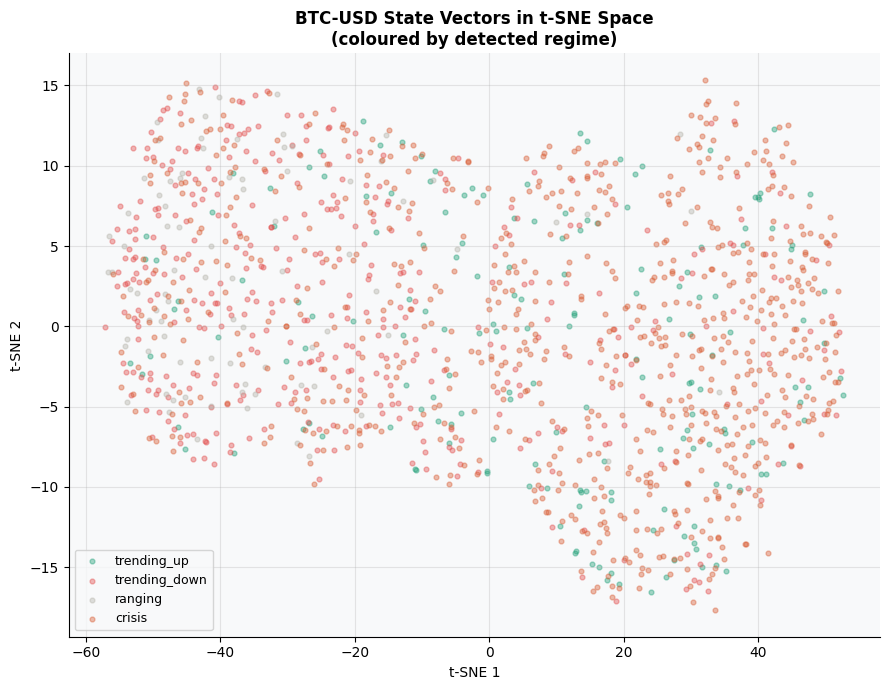

Well-separated clusters = good regime detection


In [9]:
try:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    safe  = SYMBOL.replace('-','_').replace('=','_').replace('/','_')
    spath = Path(config['data']['processed_dir']) / 'states' / f'{safe}_states.parquet'

    if spath.exists() and labels_df is not None:
        states = pd.read_parquet(spath)
        state_cols = [c for c in states.columns if c.startswith('state_')]
        common = states.index.intersection(labels_df.index)

        X      = states.loc[common, state_cols].values
        regimes_aligned = labels_df.loc[common, 'regime_name'].values

        # Subsample for speed
        if len(X) > 1500:
            idx = np.random.choice(len(X), 1500, replace=False)
            X   = X[idx]
            regimes_aligned = regimes_aligned[idx]

        scaled = StandardScaler().fit_transform(X)
        proj   = TSNE(n_components=2, random_state=42, perplexity=40).fit_transform(scaled)

        fig, ax = plt.subplots(figsize=(9, 7))
        for name, colour in RCOLOURS.items():
            mask = regimes_aligned == name
            ax.scatter(proj[mask,0], proj[mask,1], c=colour, alpha=0.4,
                        s=12, label=name)
        ax.legend(fontsize=9)
        ax.set_title(f'{SYMBOL} State Vectors in t-SNE Space\n'
                      '(coloured by detected regime)', fontweight='bold')
        ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
        plt.tight_layout()
        plt.savefig('logs/p3_05_state_tsne.png', dpi=130, bbox_inches='tight')
        plt.show()
        print('Well-separated clusters = good regime detection')
    else:
        print('State vectors or labels not found')
except ImportError:
    print('Run: pip install scikit-learn')

## 7 — Per-asset regime behaviour

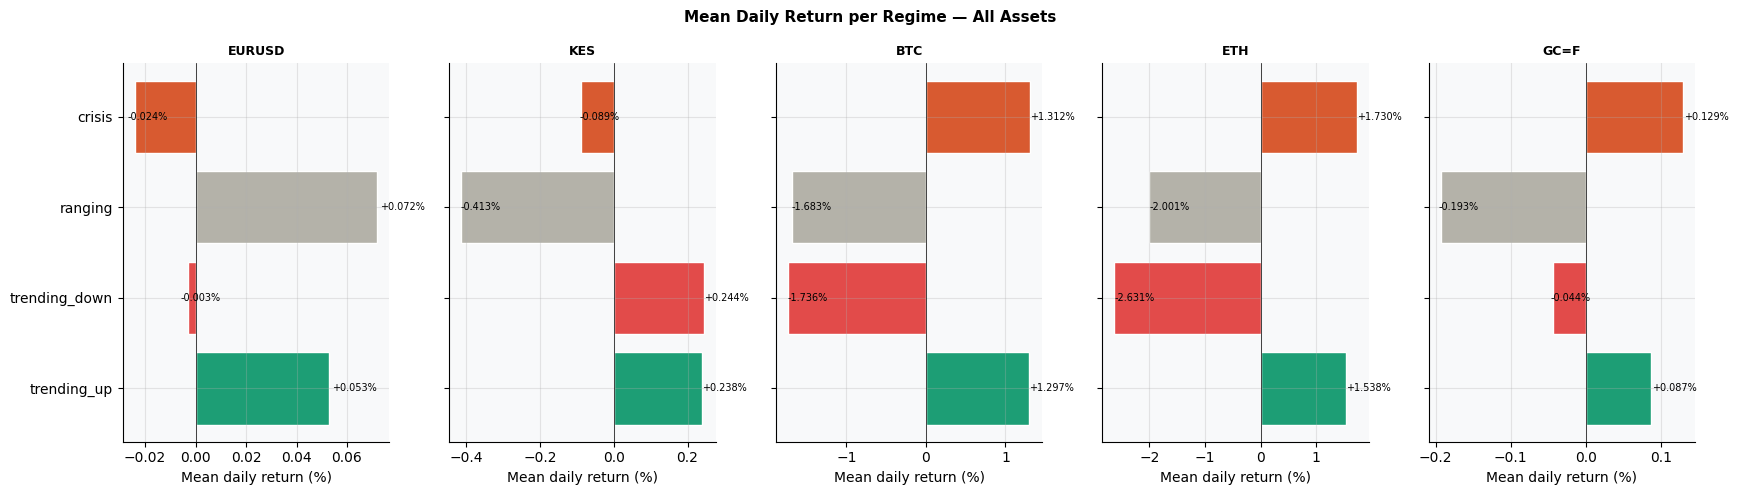

In [10]:
from src.regime.regime_analyser import _compute_asset_stats
if labels_df is not None:
    asset_stats = _compute_asset_stats(labels_df, config)

    n = len(asset_stats)
    fig, axes = plt.subplots(1, n, figsize=(3.5*n, 5), sharey=True)
    if n == 1: axes = [axes]

    for ax, (sym, df) in zip(axes, asset_stats.items()):
        colours = [RCOLOURS.get(n,'#888') for n in df.index]
        bars = ax.barh(df.index, df['mean_ret_%'], color=colours, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_xlabel('Mean daily return (%)')
        ax.set_title(sym.replace('=X','').replace('-USD',''), fontweight='bold', fontsize=9)
        for bar, v in zip(bars, df['mean_ret_%']):
            ax.text(v + (0.001 if v >= 0 else -0.003),
                     bar.get_y()+bar.get_height()/2,
                     f'{v:+.3f}%', va='center', fontsize=7)

    plt.suptitle('Mean Daily Return per Regime — All Assets', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p3_06_per_asset_regimes.png', dpi=130, bbox_inches='tight')
    plt.show()

## 8 — Regime probabilities (soft assignments)

In [11]:
prob_cols = [c for c in labels_df.columns if c.startswith('prob_')] if labels_df is not None else []

if labels_df is not None and prob_cols:
    # Focus on last 365 days for clarity
    recent = labels_df.last('365D')

    fig, axes = plt.subplots(len(prob_cols)+1, 1, figsize=(14, 10), sharex=True)

    # Price
    close_r = price_df['close'].reindex(recent.index) if price_df is not None else None
    if close_r is not None:
        axes[0].plot(close_r.index, close_r.values, color='#1a1a2e', linewidth=0.9)
        axes[0].set_ylabel('Price')
        axes[0].set_title(f'{SYMBOL} — Last 365 Days: Price + Regime Probabilities',
                           fontweight='bold')

    regime_labels_map = {
        'prob_0': 'trending_up',
        'prob_1': 'trending_down',
        'prob_2': 'ranging',
        'prob_3': 'crisis',
    }

    for ax, col in zip(axes[1:], prob_cols):
        name   = regime_labels_map.get(col, col)
        colour = RCOLOURS.get(name, '#888')
        ax.fill_between(recent.index, recent[col], alpha=0.6, color=colour)
        ax.plot(recent.index, recent[col], color=colour, linewidth=0.6)
        ax.set_ylim(0, 1)
        ax.set_ylabel(f'P({name})', fontsize=8)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.tight_layout()
    plt.savefig('logs/p3_07_regime_probs.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('High prob = HMM confident about regime. Low = transitioning.')
else:
    print('No probability columns — re-run Phase 3')

AttributeError: 'DataFrame' object has no attribute 'last'

## ✅ Phase 3 complete

```bash
python main.py --phase 4   # Next: RL specialist agents
```

Phase 4 trains three RL agents:
- **Forex agent** (EUR/USD, USD/KES) — PPO with regime conditioning
- **Crypto agent** (BTC, ETH) — SAC with on-chain features
- **Gold agent** (XAUUSD) — PPO with macro + safe-haven signals

Each agent sees the 128-d state vector **plus** the current regime label,
allowing it to adapt its trading strategy to market conditions.